In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv("/content/credit_risk_loan_default_data.csv")

In [34]:
df.shape

(50000, 20)

In [ ]:
df.head()

,Loan_ID,Customer_ID,Age,Gender,Employment_Type,Employment_Years,Annual_Income,Credit_Score,Existing_Loans,Previous_Defaults,DTI_Ratio,Loan_Amount,Loan_Tenure_Months,Interest_Rate,Loan_Purpose,EMI,Collateral_Value,Application_Date,Loan_Status,Default_Flag
0,L100000,C100000,43,Male,Self-employed,7.6,800416.0,762,2,0,0.346,1101250,60,8.69,Personal,22694.81,500600.0,2025-03-11,Approved,1
1,L100001,C100001,37,Male,Salaried,12.6,722218.0,659,0,2,0.271,597413,24,12.88,Personal,28368.44,168420.0,2024-03-16,Approved,0
2,L100002,C100002,44,Female,Salaried,5.2,547771.0,722,1,0,0.209,1165963,12,9.88,Home Improvement,102441.61,1973830.0,2025-09-01,Approved,0
3,L100003,C100003,53,Female,Salaried,4.9,540264.0,680,2,0,0.300,150237,48,9.84,Vehicle,3798.86,178399.0,2023-02-21,Approved,0
4,L100004,C100004,36,Male,Business,11.3,1010445.0,810,1,0,0.256,1005636,36,7.00,Home Improvement,31051.12,775863.0,2023-04-28,Approved,0


In [ ]:
df.tail()

,Loan_ID,Customer_ID,Age,Gender,Employment_Type,Employment_Years,Annual_Income,Credit_Score,Existing_Loans,Previous_Defaults,DTI_Ratio,Loan_Amount,Loan_Tenure_Months,Interest_Rate,Loan_Purpose,EMI,Collateral_Value,Application_Date,Loan_Status,Default_Flag
49995,L149995,C149995,39,Male,Salaried,1.9,1158354.0,775,1,0,0.414,732058,36,7.77,Home Improvement,22862.44,1263926.0,2023-01-05,Approved,0
49996,L149996,C149996,38,Male,Salaried,12.7,294313.0,636,1,0,0.164,388052,12,10.33,Personal,34175.52,61748.0,2025-08-24,Approved,0
49997,L149997,C149997,43,Female,Salaried,7.5,608496.0,631,1,0,NaN,1012189,12,10.53,Education,89237.19,344007.0,2025-02-10,Rejected,0
49998,L149998,C149998,41,Female,Salaried,10.9,889085.0,765,1,0,0.444,210116,48,9.29,Personal,5257.73,55042.0,2024-10-23,Approved,0
49999,L149999,C149999,53,Male,Salaried,10.7,417563.0,690,1,0,0.219,507642,72,9.18,Personal,9195.94,218159.0,2023-11-04,Approved,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loan_ID             50000 non-null  object 
 1   Customer_ID         50000 non-null  object 
 2   Age                 50000 non-null  int64  
 3   Gender              50000 non-null  object 
 4   Employment_Type     50000 non-null  object 
 5   Employment_Years    49800 non-null  float64
 6   Annual_Income       49850 non-null  float64
 7   Credit_Score        50000 non-null  int64  
 8   Existing_Loans      50000 non-null  int64  
 9   Previous_Defaults   50000 non-null  int64  
 10  DTI_Ratio           49800 non-null  float64
 11  Loan_Amount         50000 non-null  int64  
 12  Loan_Tenure_Months  50000 non-null  int64  
 13  Interest_Rate       50000 non-null  float64
 14  Loan_Purpose        50000 non-null  object 
 15  EMI                 50000 non-null  float64
 16  Coll

In [ ]:
df.describe()

,Age,Employment_Years,Annual_Income,Credit_Score,Existing_Loans,Previous_Defaults,DTI_Ratio,Loan_Amount,Loan_Tenure_Months,Interest_Rate,EMI,Collateral_Value,Default_Flag
count,50000.000000,49800.000000,4.985000e+04,50000.000000,50000.000000,50000.000000,49800.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,4.985000e+04,50000.000000
mean,38.179680,8.002737,7.559432e+05,689.195440,1.299300,0.104000,0.267961,7.418655e+05,43.284840,10.076069,24426.449733,5.506622e+05,0.078300
std,9.605092,5.041329,4.472472e+05,64.521353,1.141887,0.341447,0.106063,5.434279e+05,17.167265,1.738564,23006.859422,6.481969e+05,0.268646
min,21.000000,0.500000,1.800000e+05,419.000000,0.000000,0.000000,0.050000,5.000000e+04,12.000000,7.000000,840.280000,1.000000e+00,0.000000
25%,31.000000,4.300000,4.483900e+05,645.000000,0.000000,0.000000,0.194000,3.433112e+05,36.000000,8.820000,9736.475000,1.181808e+05,0.000000
50%,38.000000,7.000000,6.486455e+05,687.000000,1.000000,0.000000,0.267000,5.923890e+05,48.000000,10.050000,17550.535000,3.172280e+05,0.000000
75%,45.000000,10.600000,9.394485e+05,731.000000,2.000000,0.000000,0.339000,9.814688e+05,60.000000,11.270000,31143.317500,7.365850e+05,0.000000
max,70.000000,35.000000,5.000000e+06,850.000000,8.000000,4.000000,0.774000,2.500000e+06,84.000000,17.540000,223328.380000,4.495759e+06,1.000000


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Customer_ID,0
Age,0
Gender,0
Employment_Type,0
Employment_Years,200
Annual_Income,150
Credit_Score,0
Existing_Loans,0
Previous_Defaults,0


In [ ]:
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_pct[missing_pct > 0]

,0
Employment_Years,0.4
Annual_Income,0.3
DTI_Ratio,0.4
Collateral_Value,0.3


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Loan_ID
Loan_ID
L149983    1
L149982    1
L149981    1
L149980    1
L149979    1
          ..
L100004    1
L100003    1
L100002    1
L100001    1
L100000    1
Name: count, Length: 50000, dtype: int64

Customer_ID
Customer_ID
C149983    1
C149982    1
C149981    1
C149980    1
C149979    1
          ..
C100004    1
C100003    1
C100002    1
C100001    1
C100000    1
Name: count, Length: 50000, dtype: int64

Gender
Gender
Male      33976
Female    16024
Name: count, dtype: int64

Employment_Type
Employment_Type
Salaried         28930
Self-employed    13480
Business          7590
Name: count, dtype: int64

Loan_Purpose
Loan_Purpose
Personal            13999
Vehicle             11176
Home Improvement     8973
Education            5876
Business             5033
Medical              4943
Name: count, dtype: int64

Application_Date
Application_Date
2024-06-19    66
2025-03-02    66
2025-05-25    65
2025-03-16    64
2023-09-21    64
              ..
2023-09-25    30
2023-02-24    30
2024-01-3

In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,50000.0,38.179680,9.605092,21.00,31.000,38.000,45.0000,70.000
Employment_Years,49800.0,8.002737,5.041329,0.50,4.300,7.000,10.6000,35.000
Annual_Income,49850.0,755943.248124,447247.209979,180000.00,448390.000,648645.500,939448.5000,5000000.000
Credit_Score,50000.0,689.195440,64.521353,419.00,645.000,687.000,731.0000,850.000
Existing_Loans,50000.0,1.299300,1.141887,0.00,0.000,1.000,2.0000,8.000
Previous_Defaults,50000.0,0.104000,0.341447,0.00,0.000,0.000,0.0000,4.000
DTI_Ratio,49800.0,0.267961,0.106063,0.05,0.194,0.267,0.3390,0.774
Loan_Amount,50000.0,741865.495520,543427.910230,50000.00,343311.250,592389.000,981468.7500,2500000.000
Loan_Tenure_Months,50000.0,43.284840,17.167265,12.00,36.000,48.000,60.0000,84.000
Interest_Rate,50000.0,10.076069,1.738564,7.00,8.820,10.050,11.2700,17.540


In [ ]:
df["Default_Flag"].value_counts()
df["Default_Flag"].value_counts(normalize=True) * 100

,proportion
Default_Flag,
0,92.17
1,7.83


In [ ]:
approved = df[df["Loan_Status"] == "Approved"]
default_rate = approved["Default_Flag"].mean() * 100
print(f"Default Rate: {default_rate:.2f}%")

Default Rate: 12.68%


In [ ]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print(df["Loan_Status"].value_counts())

(50000, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loan_ID             50000 non-null  object 
 1   Customer_ID         50000 non-null  object 
 2   Age                 50000 non-null  int64  
 3   Gender              50000 non-null  object 
 4   Employment_Type     50000 non-null  object 
 5   Employment_Years    49800 non-null  float64
 6   Annual_Income       49850 non-null  float64
 7   Credit_Score        50000 non-null  int64  
 8   Existing_Loans      50000 non-null  int64  
 9   Previous_Defaults   50000 non-null  int64  
 10  DTI_Ratio           49800 non-null  float64
 11  Loan_Amount         50000 non-null  int64  
 12  Loan_Tenure_Months  50000 non-null  int64  
 13  Interest_Rate       50000 non-null  float64
 14  Loan_Purpose        50000 non-null  object 
 15  EMI                 50000 non-null  float

#Data Understanding & Quality Check

# Dataset Overview

* Total Records: 50,000
* Total Columns: 20
* Approved Loans: 30,887
* Rejected Applications: 19,113
* Duplicate Records: 0

# Data Types

* Numerical Columns: 13
* Categorical/Object Columns: 7
* Application_Date is currently stored as object and will be converted to datetime.

# Missing Values

* Employment_Years: 200 (0.40%)
* Annual_Income: 150 (0.30%)
* DTI_Ratio: 200 (0.40%)
* Collateral_Value: 150 (0.30%)
* Total Missing Cells: 700

# Data Quality Findings

* No duplicate records were found.
* Missing values are present in four numerical columns.
* Missing-value percentage is very low.
* Application_Date requires datatype conversion.
* Default_Flag is a binary variable:
  0 = No Default
  1 = Default

# Next Step

Perform data cleaning by handling missing values, converting Application_Date to datetime, validating data types and checking potential outliers.


In [ ]:
df["Application_Date"] = pd.to_datetime(df["Application_Date"])
df["Application_Date"].dtype

dtype('<M8[ns]')

In [ ]:
df.isnull().sum()[df.isnull().sum()>0]

,0
Employment_Years,200
Annual_Income,150
DTI_Ratio,200
Collateral_Value,150


In [ ]:
df["Employment_Years"]= df["Employment_Years"].fillna(df["Employment_Years"].median())
df["Annual_Income"]= df["Annual_Income"].fillna(df["Annual_Income"].median())
df["DTI_Ratio"]= df["DTI_Ratio"].fillna(df["DTI_Ratio"].median())
df["Collateral_Value"]= df["Collateral_Value"].fillna(df["Collateral_Value"].median())
df.isnull().sum()

,0
Loan_ID,0
Customer_ID,0
Age,0
Gender,0
Employment_Type,0
Employment_Years,0
Annual_Income,0
Credit_Score,0
Existing_Loans,0
Previous_Defaults,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
categorical_cols = [
    "Gender",
    "Employment_Type",
    "Loan_Purpose",
    "Loan_Status"
]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


Gender:
['Male' 'Female']

Employment_Type:
['Self-employed' 'Salaried' 'Business']

Loan_Purpose:
['Personal' 'Home Improvement' 'Vehicle' 'Education' 'Medical' 'Business']

Loan_Status:
['Approved' 'Rejected']


In [ ]:
print("Age:", df["Age"].min(), "-", df["Age"].max())
print("Credit Score:", df["Credit_Score"].min(), "-", df["Credit_Score"].max())
print("DTI Ratio:", df["DTI_Ratio"].min(), "-", df["DTI_Ratio"].max())
print("Interest Rate:", df["Interest_Rate"].min(), "-", df["Interest_Rate"].max())

Age: 21 - 70
Credit Score: 419 - 850
DTI Ratio: 0.05 - 0.774
Interest Rate: 7.0 - 17.54


In [ ]:
print("Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Shape: (50000, 20)
Missing Values: 0
Duplicate Rows: 0


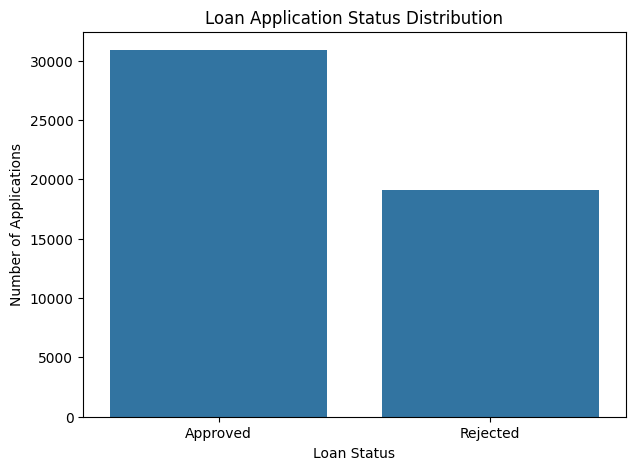

In [ ]:
loan_status_counts = df["Loan_Status"].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(
    x=loan_status_counts.index,
    y=loan_status_counts.values
)

plt.title("Loan Application Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.show()

In [ ]:
loan_status_pct = (
    df["Loan_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(loan_status_pct)

Loan_Status
Approved    61.77
Rejected    38.23
Name: proportion, dtype: float64


### Business Insight

The loan application portfolio contains both approved and rejected applications.
The analysis shows the distribution of applications across the two loan status categories.

This provides an initial view of the loan approval funnel and helps understand the overall composition of the portfolio.

In [ ]:
approved = df[df["Loan_Status"] == "Approved"].copy()
approved.shape

(30887, 20)

In [ ]:
default_counts = approved["Default_Flag"].value_counts()
print(default_counts)

Default_Flag
0    26972
1     3915
Name: count, dtype: int64


In [ ]:
default_counts.index = default_counts.index.map({
    0: "No Default",
    1: "Default"
})
print(default_counts)

Default_Flag
No Default    26972
Default        3915
Name: count, dtype: int64


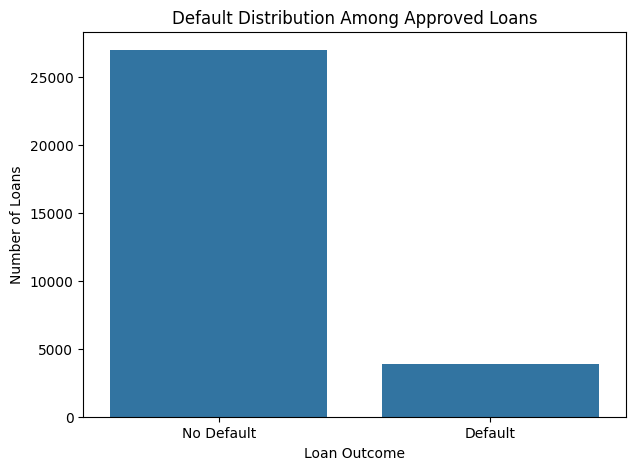

In [ ]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=default_counts.index,
    y=default_counts.values
)
plt.title("Default Distribution Among Approved Loans")
plt.xlabel("Loan Outcome")
plt.ylabel("Number of Loans")

plt.show()

In [ ]:
default_rate = approved["Default_Flag"].mean() * 100
print(f"Default Rate: {default_rate:.2f}%")

Default Rate: 12.68%


In [ ]:
default_pct = (
    approved["Default_Flag"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
default_pct.index = default_pct.index.map({
    0: "No Default",
    1: "Default"
})
print(default_pct)

Default_Flag
No Default    87.32
Default       12.68
Name: proportion, dtype: float64


### Business Insight

The analysis shows the distribution of default and non-default loans among approved applications.

The overall default rate is approximately 12.68% among approved loans.

This indicates that a meaningful portion of the approved loan portfolio carries default risk. Further analysis is required to identify the customer and loan characteristics associated with higher default rates.

### Next Analysis

The next step is to analyze default rates across different credit score segments.

In [ ]:
approved["Credit_Score_Group"] = pd.cut(
    approved["Credit_Score"],
    bins=[0, 599, 649, 699, 749, 850],
    labels=[
        "<600",
        "600-649",
        "650-699",
        "700-749",
        "750+"
    ]
)

In [ ]:
credit_default_rate = (
    approved
    .groupby("Credit_Score_Group", observed=True)["Default_Flag"]
    .mean()
    .mul(100)
    .round(2)
)
print(credit_default_rate)

Credit_Score_Group
<600       27.57
600-649    18.25
650-699    13.04
700-749     9.25
750+        5.43
Name: Default_Flag, dtype: float64


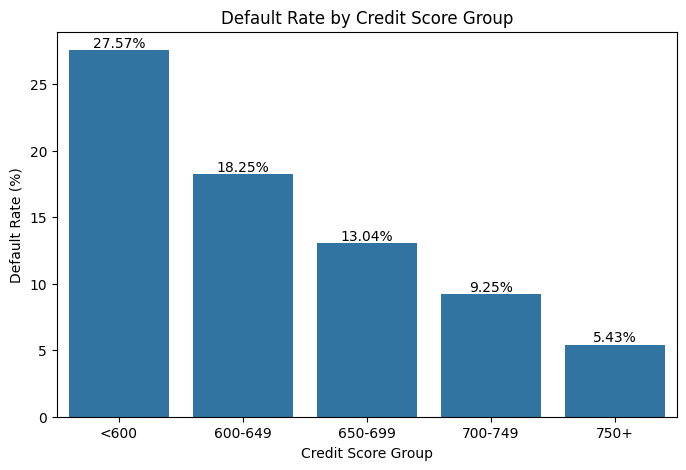

In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=credit_default_rate.index,
    y=credit_default_rate.values
)
plt.title("Default Rate by Credit Score Group")
plt.xlabel("Credit Score Group")
plt.ylabel("Default Rate (%)")

for i, value in enumerate(credit_default_rate.values):
    ax.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha="center"
    )
plt.show()

### Business Insight

The analysis shows that default rates vary across different credit score groups.

Lower credit score segments generally indicate higher credit risk, while higher credit score segments tend to have lower default rates.

This suggests that credit score can be an important factor for monitoring loan portfolio risk.

Further analysis will examine whether other factors such as DTI ratio, previous defaults, income, and loan amount show similar patterns.


In [ ]:
approved["DTI_Group"] = pd.cut(
    approved["DTI_Ratio"],
    bins=[0, 0.20, 0.35, 0.50, 1],
    labels=[
        "<20%",
        "20-35%",
        "35-50%",
        "50%+"
    ],
    include_lowest=True
)

In [ ]:
dti_default_rate = (
    approved
    .groupby("DTI_Group", observed=True)["Default_Flag"]
    .mean()
    .mul(100)
    .round(2)
)
print(dti_default_rate)

DTI_Group
<20%       6.97
20-35%    12.51
35-50%    19.84
50%+      30.11
Name: Default_Flag, dtype: float64


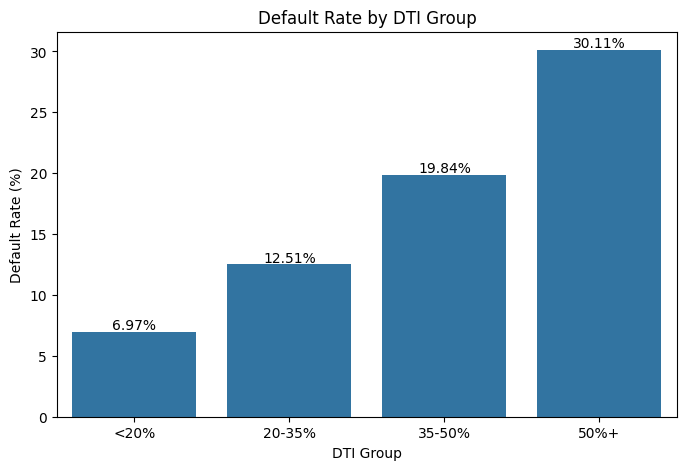

In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=dti_default_rate.index,
    y=dti_default_rate.values
)
plt.title("Default Rate by DTI Group")
plt.xlabel("DTI Group")
plt.ylabel("Default Rate (%)")

for i, value in enumerate(dti_default_rate.values):
    ax.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha="center"
    )
plt.show()

In [ ]:
print(dti_default_rate)

DTI_Group
<20%       6.97
20-35%    12.55
35-50%    19.84
50%+      30.11
Name: Default_Flag, dtype: float64


### Business Insight

The analysis shows that default rates vary across different DTI groups.

Customers with higher DTI ratios generally have a higher debt burden relative to their income, which can indicate increased repayment risk.

Therefore, DTI Ratio can be considered an important metric for monitoring credit risk and identifying potentially high-risk customer segments.

In [ ]:
print(sorted(approved["Previous_Defaults"].unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [ ]:
previous_default_rate = (
    approved
    .groupby("Previous_Defaults")["Default_Flag"]
    .mean()
    .mul(100)
    .round(2)
)
print(previous_default_rate)

Previous_Defaults
0    11.19
1    26.23
2    42.91
3    59.26
4    66.67
Name: Default_Flag, dtype: float64


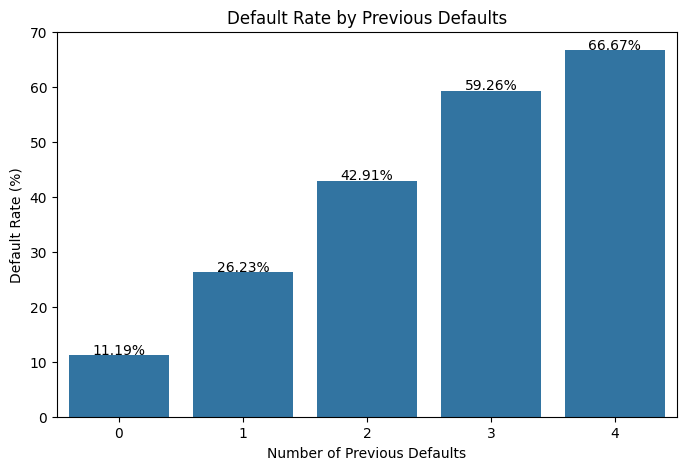

In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=previous_default_rate.index,
    y=previous_default_rate.values
)

plt.title("Default Rate by Previous Defaults")
plt.xlabel("Number of Previous Defaults")
plt.ylabel("Default Rate (%)")

for i, value in enumerate(previous_default_rate.values):
    ax.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha="center"
    )
plt.show()

In [ ]:
print(previous_default_rate)

Previous_Defaults
0    11.19
1    26.23
2    42.91
3    59.26
4    66.67
Name: Default_Flag, dtype: float64


### Business Insight

The analysis compares current loan default rates across customers with different numbers of previous defaults.

Customers with a history of previous loan defaults may represent a higher-risk segment. The analysis helps determine whether previous default history is associated with higher current default rates.

This metric can be used by lenders as an important factor for credit risk monitoring.


In [ ]:
print(approved["Loan_Purpose"].value_counts())

Loan_Purpose
Personal            8653
Vehicle             6870
Home Improvement    5576
Education           3644
Business            3078
Medical             3066
Name: count, dtype: int64


In [ ]:
purpose_default_rate = (
    approved
    .groupby("Loan_Purpose")["Default_Flag"]
    .mean()
    .mul(100)
    .round(2)
)
print(purpose_default_rate)

Loan_Purpose
Business            12.87
Education           11.77
Home Improvement    12.86
Medical             12.72
Personal            12.17
Vehicle             13.54
Name: Default_Flag, dtype: float64


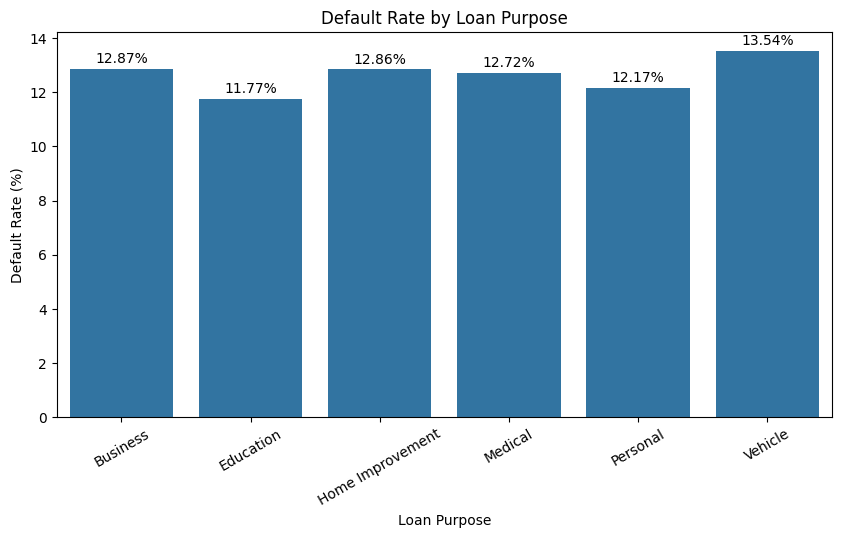

In [ ]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=purpose_default_rate.index,
    y=purpose_default_rate.values
)

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30)

for i, value in enumerate(purpose_default_rate.values):
    ax.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha="center"
    )
plt.show()

In [ ]:
print(purpose_default_rate.sort_values(ascending=False))

Loan_Purpose
Vehicle             13.54
Business            12.87
Home Improvement    12.86
Medical             12.72
Personal            12.17
Education           11.77
Name: Default_Flag, dtype: float64


### Business Insight

The analysis compares loan default rates across different loan purposes.

Default rates vary across loan-purpose categories, indicating that the purpose of borrowing may be associated with different levels of credit risk.

The loan-purpose segments with relatively higher default rates should be monitored more closely by the lending organization.

In [ ]:
print(approved["Employment_Type"].value_counts())

Employment_Type
Salaried         17777
Self-employed     8429
Business          4681
Name: count, dtype: int64


In [ ]:
employment_default_rate = (
    approved
    .groupby("Employment_Type")["Default_Flag"]
    .mean()
    .mul(100)
    .round(2)
)
print(employment_default_rate)

Employment_Type
Business         12.33
Salaried         12.77
Self-employed    12.67
Name: Default_Flag, dtype: float64


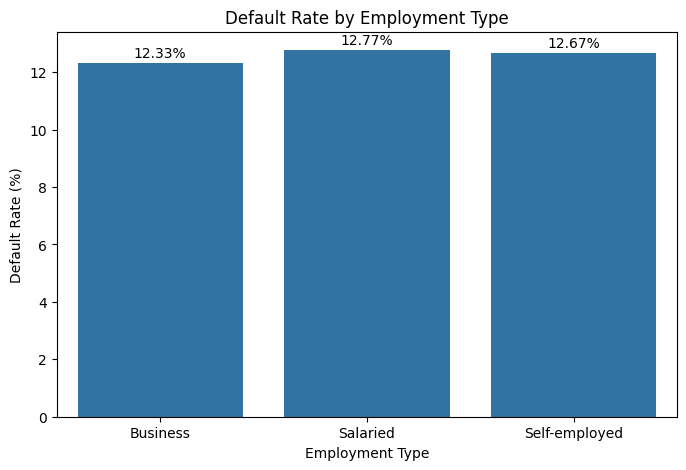

In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=employment_default_rate.index,
    y=employment_default_rate.values
)

plt.title("Default Rate by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Default Rate (%)")

for i, value in enumerate(employment_default_rate.values):
    ax.text(
        i,
        value + 0.2,
        f"{value:.2f}%",
        ha="center"
    )
plt.show()

In [ ]:
print(employment_default_rate.sort_values(ascending=False))

Employment_Type
Salaried         12.77
Self-employed    12.67
Business         12.33
Name: Default_Flag, dtype: float64


### Business Insight

The analysis compares loan default rates across different employment types.

Default rates vary across employment categories, which may indicate differences in income stability or repayment behavior.

Employment segments with relatively higher default rates can be monitored more closely as part of credit risk analysis.

In [ ]:
print(approved["Annual_Income"].describe())

count    3.088700e+04
mean     7.676405e+05
std      4.569326e+05
min      1.800000e+05
25%      4.547485e+05
50%      6.582190e+05
75%      9.520505e+05
max      5.000000e+06
Name: Annual_Income, dtype: float64


In [ ]:
approved["Income_Group"] = pd.qcut(
    approved["Annual_Income"],
    q=4,
    labels=[
        "Low Income",
        "Lower-Middle Income",
        "Upper-Middle Income",
        "High Income"
    ]
)
print(approved[["Annual_Income", "Income_Group"]])

       Annual_Income         Income_Group
0           800416.0  Upper-Middle Income
1           722218.0  Upper-Middle Income
2           547771.0  Lower-Middle Income
3           540264.0  Lower-Middle Income
4          1010445.0          High Income
...              ...                  ...
49994       847739.0  Upper-Middle Income
49995      1158354.0          High Income
49996       294313.0           Low Income
49998       889085.0  Upper-Middle Income
49999       417563.0           Low Income

[30887 rows x 2 columns]


FINAL BUSINESS INSIGHTS

1. Overall Loan Performance
The dataset contains 50,000 loan applications, with an overall approval rate of 61.77% and rejection rate of 38.23%.

2. Credit Risk and Previous Defaults
Applicants with previous defaults had a lower approval rate of 57.69%, compared with 62.19% for applicants with no previous defaults. Previous repayment history is therefore an important risk indicator.

3. DTI and Loan Approval
Approval rate decreased from 62.70% for low-DTI applicants to 59.01% for high-DTI applicants. Higher debt burden is associated with lower approval rates.

4. Income and Loan Amount
Higher-income applicants generally requested larger loan amounts and had higher average EMIs. This shows a positive relationship between income level, loan size, and EMI.

5. Employment Type
Approval rates were relatively similar across employment types. Self-employed applicants had the highest approval rate at 62.53%, while salaried applicants had 61.45%. Employment type alone does not appear to be a strong differentiator.

6. Monthly Loan Performance
Monthly approval rates remained relatively stable between approximately 59% and 64% from 2023 to 2025. There was no major long-term upward or downward trend.

7. Business Recommendation
The bank should give greater attention to previous default history and DTI ratio when assessing credit risk, while considering income, loan amount, and other customer attributes together rather than relying on a single factor.

                     FINAL BUSINESS INSIGHTS

## 1. Overall Loan Performance

Business Finding:

The dataset contains 50,000 loan applications. Out of these, 30,887 applications were approved and 19,113 were rejected.

Approval Rate: 61.77%
Rejection Rate: 38.23%

Business Insights:

The overall approval rate is 61.77%, which provides a baseline for evaluating the bank's loan approval performance and identifying factors associated with loan rejection.

## 2. Previous Default Impact

Business Finding:

Applicants with no previous default had an approval rate of 62.19%, while applicants with previous defaults had an approval rate of 57.69%.

Difference: 4.50 percentage points

Business Insights:

Applicants with previous defaults have a lower approval rate than applicants with no previous defaults. This indicates that previous repayment history is an important indicator of credit risk and should be considered during loan approval decisions.

## 3. DTI Ratio Impact

Business Finding:

The approval rate was 62.70% for Low DTI applicants, 60.31% for Medium DTI applicants, and 59.01% for High DTI applicants.

Business Insight:

The approval rate decreases as the DTI ratio increases. This suggests that applicants with a higher debt burden are associated with lower loan approval rates.

Note:
The High DTI group contains only 788 applications, so this result should be interpreted with some caution.

## 4. Income and Loan Amount

Business Finding:

Average loan amount increased with income level.

Low Income: ₹243,059
Middle Income: ₹459,761
High Income: ₹772,581
Very High Income: ₹1,354,340

Business Insights:

Higher-income applicants generally requested larger loan amounts and had higher average EMIs. This indicates a positive relationship between income level, requested loan amount, and EMI.

## 5. Employment Type Analysis

Business Finding:

Approval rates were relatively similar across employment types.

Self-employed: 62.53%
Business: 61.67%
Salaried: 61.45%

Difference between highest and lowest approval rate: 1.08 percentage points

Business Insights:

Employment type alone does not appear to be a strong differentiator of loan approval in this dataset. The approval rates across employment categories are relatively close.

## 6. Monthly Loan Trend

Business Finding:

The monthly loan approval rate remained relatively stable between approximately 59% and 64% from 2023 to 2025.

Highest Approval Rate:
August 2024 — 64.14%

Lowest Approval Rate:
June 2024 — 59.16%

Highest Application Volume:
March 2025 — 1,540 applications

Business Insights:

The loan approval rate remained relatively stable over the three-year period, with no major long-term upward or downward trend. Monthly fluctuations can help management monitor changes in loan demand and approval performance.

# 7. Final Business Conclusion

The analysis of 50,000 loan applications shows that previous default history and DTI ratio are important indicators associated with loan approval outcomes.

Applicants with previous defaults had a lower approval rate than those without previous defaults. Similarly, approval rates decreased as DTI increased, indicating that higher debt burden is associated with lower approval rates.

Higher-income applicants generally requested larger loans and had higher average EMIs, while employment type showed only a small difference in approval rates.

Overall, loan approval performance remained relatively stable from 2023 to 2025.

The analysis suggests that loan approval decisions should consider multiple customer and financial risk factors together rather than relying on a single attribute.

# 8. Business Recommendations

1. Strengthen Default History Checks
Previous default history is associated with lower approval rates. The bank should carefully evaluate customers with previous repayment issues before approving new loans.

2. Monitor High-DTI Applicants
Applicants with higher DTI ratios show lower approval rates. Additional affordability and repayment-capacity checks can help manage credit risk.

3. Consider Multiple Risk Factors
Loan approval decisions should not depend on a single factor. Credit score, DTI ratio, previous defaults, income, loan amount, and other customer characteristics should be evaluated together.

4. Match Loan Amount with Repayment Capacity
Higher-income customers generally request larger loans and have higher EMIs. Loan amounts should be evaluated against income and overall repayment capacity.

5. Monitor Approval Trends
Although approval rates remained relatively stable, monthly monitoring can help identify unexpected changes in loan demand or approval performance.

#9. Conclusion
This project provided a comprehensive analysis of loan application and approval patterns using Python, SQL, and Power BI. The analysis helped identify relationships between loan approval and factors such as credit score, DTI, income, employment type, and previous default history. The interactive Power BI dashboard brings these insights together and enables users to explore loan performance across different segments. Overall, the project demonstrates how data analytics can support better credit risk assessment and data-driven loan approval decisions.
